# 🧠 Stroke Prediction — EDA & Data Processing

<div align="center">
  <img src="https://img.icons8.com/color/96/000000/brain.png" width="60"/>
</div>

<br>

<span style="font-size:1.1em;">
Este notebook reorganiza el análisis de predicción de ACV (stroke) en un flujo profesional, visual y didáctico. Se mantiene el contenido analítico, pero se mejora la presentación y claridad.
</span>

---

## 🎯 Objetivos

- **Carga y partición** del dataset en entrenamiento y validación.
- **EDA** (análisis exploratorio) solo sobre el set de entrenamiento.
- Análisis de **valores faltantes** y la categoría `"Unknown"` en `smoking_status`.
- Preprocesamiento seguro contra *leakage*.
- Construcción de matrices de features procesadas para modelado.
- Estudio de la asociación entre variables y el target usando métricas lineales y no lineales.

<br>
<details>
<summary>ℹ️ <b>Tips para navegar este notebook</b></summary>

- Las secciones están claramente marcadas y cada bloque de código incluye comentarios aclaratorios.
- Se utilizan gráficos y tablas para facilitar la interpretación.
- Al final de cada sección clave encontrarás conclusiones o recomendaciones.
</details>


## 1. ⚙️ Setup y carga de datos

> En esta sección se importan las librerías necesarias y se carga el dataset. Además, se configuran opciones visuales para que los gráficos y tablas sean más claros y agradables.


In [2]:
# 📦 Importación de librerías y configuración visual
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split



In [3]:
# Mejoras visuales para pandas y matplotlib
pd.set_option("display.max_columns", 100)
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = False
sns.set_palette("Set2")  # Paleta de colores amigable
sns.set_style("whitegrid")


# 📂 Carga del dataset
df = pd.read_csv("../datasets/healthcare-dataset-stroke-data.csv")
df.head()


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [5]:
df = df.drop(columns=['id'])

In [6]:
df['stroke'].value_counts()  # desbalance

stroke
0    4861
1     249
Name: count, dtype: int64

In [7]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

### Distribución del target

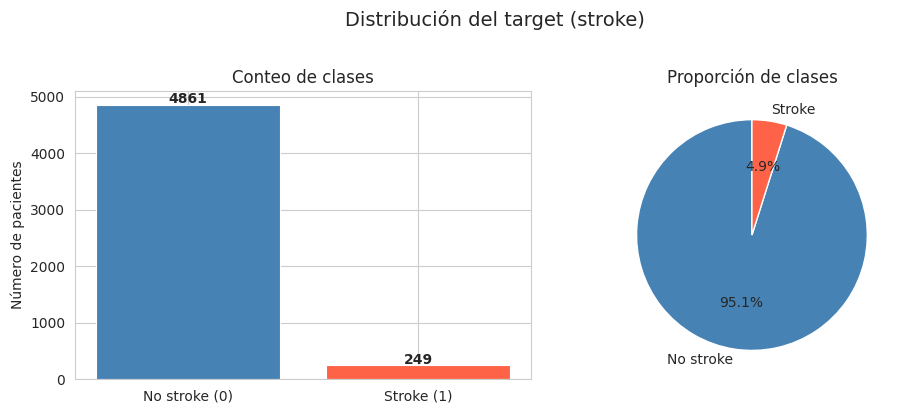

Ratio de desbalanceo: 19.5:1


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Conteo absoluto
counts = df["stroke"].value_counts()
axes[0].bar(["No stroke (0)", "Stroke (1)"], counts.values,
            color=["steelblue", "tomato"], edgecolor="white", linewidth=0.8)
axes[0].set_title("Conteo de clases")
axes[0].set_ylabel("Número de pacientes")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha="center", fontweight="bold")

# Proporción
axes[1].pie(counts.values, labels=["No stroke", "Stroke"],
            autopct="%1.1f%%", colors=["steelblue", "tomato"],
            startangle=90, wedgeprops={"edgecolor": "white"})
axes[1].set_title("Proporción de clases")

plt.suptitle("Distribución del target (stroke)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Ratio de desbalanceo: {counts[0]/counts[1]:.1f}:1")

### Nulos
Única columna con nulos es BMI

In [9]:
# Explorar si los nulos de bmi tienen algún patrón
print("Distribución de stroke en filas CON nulos en bmi:")
print(df[df["bmi"].isnull()]["stroke"].value_counts(normalize=True).round(3))
print("\nDistribución de stroke en filas SIN nulos:")
print(df[df["bmi"].notna()]["stroke"].value_counts(normalize=True).round(3))

Distribución de stroke en filas CON nulos en bmi:
stroke
0    0.801
1    0.199
Name: proportion, dtype: float64

Distribución de stroke en filas SIN nulos:
stroke
0    0.957
1    0.043
Name: proportion, dtype: float64


## 2. ✂️ Train / test split

> Se separa el dataset en entrenamiento y validación, manteniendo la proporción de la variable objetivo (*stratified split*). Esto es clave para evitar sesgos y asegurar una evaluación justa del modelo.


In [10]:
# ---
# 🔀 Split de datos en entrenamiento y validación
# Se utiliza stratify para mantener la proporción de casos de stroke en ambos sets
X = df.drop(columns="stroke")
y = df["stroke"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.4,
    stratify=y,
    random_state=42
)

split_summary = pd.DataFrame({
    "set": ["Train", "Test"],
    "rows": [len(X_train), len(X_test)],
    "stroke_rate (%)": [
        round(y_train.mean() * 100, 2),
        round(y_test.mean() * 100, 2)
    ]
})

print("Split summary:")
display(split_summary)


Split summary:


,set,rows,stroke_rate (%)
0,Train,3066,4.86
1,Test,2044,4.89


In [11]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 3066 entries, 3135 to 5052
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             3066 non-null   str    
 1   age                3066 non-null   float64
 2   hypertension       3066 non-null   int64  
 3   heart_disease      3066 non-null   int64  
 4   ever_married       3066 non-null   str    
 5   work_type          3066 non-null   str    
 6   Residence_type     3066 non-null   str    
 7   avg_glucose_level  3066 non-null   float64
 8   bmi                2939 non-null   float64
 9   smoking_status     3066 non-null   str    
dtypes: float64(3), int64(2), str(5)
memory usage: 263.5 KB


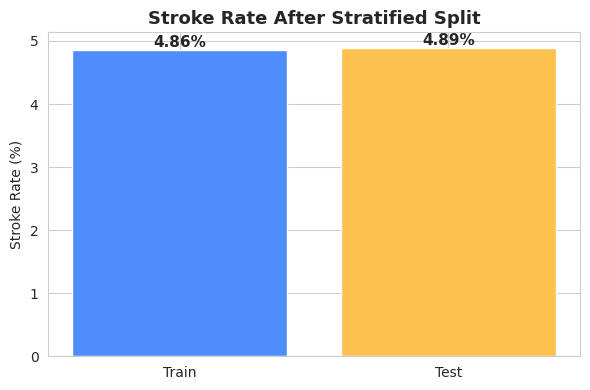


🔎 KEY OBSERVATIONS
- Train size: 3066 | Test size: 2044
- Stroke rate (train): 4.86%
- Stroke rate (test): 4.89%
- El split estratificado preserva la distribución de clases en ambos sets.


In [12]:
# ---
# 📊 Visualización de la proporción de stroke tras el split
plt.figure(figsize=(6, 4))

train_val_rates = [y_train.mean() * 100, y_test.mean() * 100]
labels = ["Train", "Test"]

bars = plt.bar(labels, train_val_rates, color=["#4F8DFD", "#FDC14F"])
plt.title("Stroke Rate After Stratified Split", fontsize=13, fontweight="bold")
plt.ylabel("Stroke Rate (%)")

for bar, val in zip(bars, train_val_rates):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{val:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("🔎 KEY OBSERVATIONS")
print("=" * 60)
print(f"- Train size: {len(X_train)} | Test size: {len(X_test)}")
print(f"- Stroke rate (train): {y_train.mean()*100:.2f}%")
print(f"- Stroke rate (test): {y_test.mean()*100:.2f}%")
print("- El split estratificado preserva la distribución de clases en ambos sets.")


## 3. 🧩 Tipado de variables y EDA sobre entrenamiento

> Todo el análisis exploratorio se realiza **solo sobre el set de entrenamiento** para evitar *leakage* de información hacia la validación.


In [13]:
# Feature typing
num_cols = ["age", "avg_glucose_level", "bmi"]

cat_cols = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status", "hypertension", "heart_disease"]

print("Numerical variables:", num_cols)
print("Categorical variables:", cat_cols)

Numerical variables: ['age', 'avg_glucose_level', 'bmi']
Categorical variables: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'hypertension', 'heart_disease']


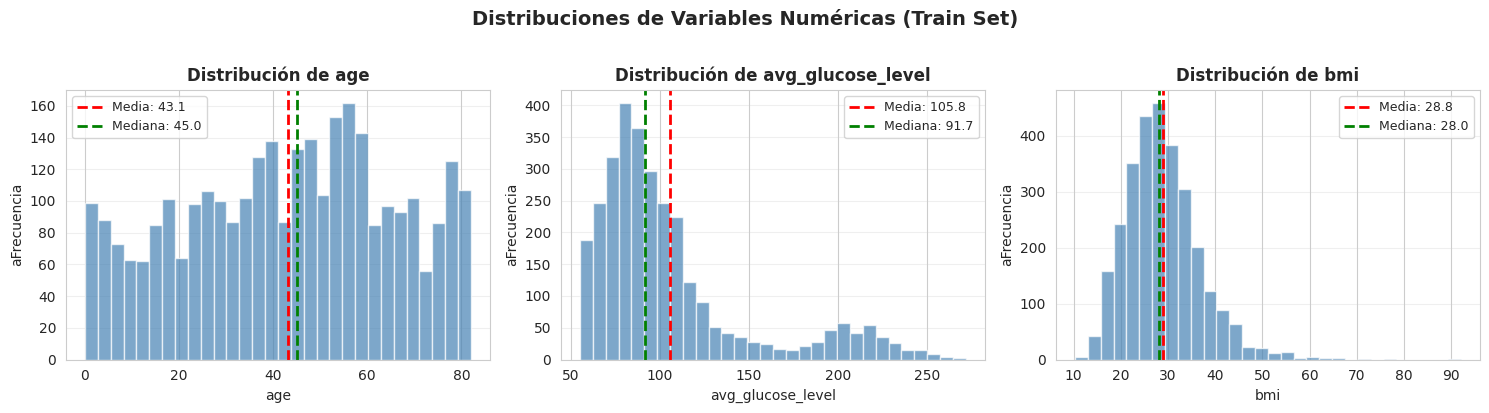


ESTADÍSTICAS DE VARIABLES NUMÉRICAS
           age  avg_glucose_level      bmi
count  3066.00            3066.00  2939.00
mean     43.13             105.82    28.84
std      22.39              44.98     7.90
min       0.08              55.12    10.30
25%      25.00              77.23    23.50
50%      45.00              91.66    28.00
75%      60.00             113.28    33.10
max      82.00             271.74    92.00


In [14]:
# Distribuciones de variables numéricas en el set de entrenamiento
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, col in enumerate(num_cols):
    # Histograma
    axes[idx].hist(X_train[col].dropna(), bins=30, color="steelblue", 
                   edgecolor="white", alpha=0.7)
    axes[idx].set_title(f"Distribución de {col}", fontweight="bold")
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel("aFrecuencia")
    axes[idx].grid(axis="y", alpha=0.3)
    
    # Estadísticas
    mean_val = X_train[col].mean()
    median_val = X_train[col].median()
    axes[idx].axvline(mean_val, color="red", linestyle="--", linewidth=2, label=f"Media: {mean_val:.1f}")
    axes[idx].axvline(median_val, color="green", linestyle="--", linewidth=2, label=f"Mediana: {median_val:.1f}")
    axes[idx].legend(fontsize=9)

plt.suptitle("Distribuciones de Variables Numéricas (Train Set)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Estadísticas resumidas
print("\n" + "="*60)
print("ESTADÍSTICAS DE VARIABLES NUMÉRICAS")
print("="*60)
print(X_train[num_cols].describe().round(2))

## 4. 🤖 KNN Basado en Variables Numéricas

> Modelo **K-Nearest Neighbors** entrenado únicamente con variables numéricas (age, avg_glucose_level, bmi) para detectar pacientes con ACV. El objetivo es **maximizar Recall** para y=1 (Stroke Detection)


In [16]:
# ============================================================
# KNN CON VARIABLES NUMÉRICAS — Prioridad: detectar Stroke=1
# ============================================================
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve,
                             recall_score)
from sklearn.impute import SimpleImputer

# ---
# Preparar features numéricas
X_train_num = X_train[num_cols].copy()
X_test_num  = X_test[num_cols].copy()

# Imputar NaN en bmi con la mediana del train
imputer = SimpleImputer(strategy="median")
X_train_num = imputer.fit_transform(X_train_num)
X_test_num  = imputer.transform(X_test_num)

# Escalar (KNN es sensible a la escala)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled  = scaler.transform(X_test_num)


Mejor K (por Recall Stroke=1): 1  (recall: 0.1400)


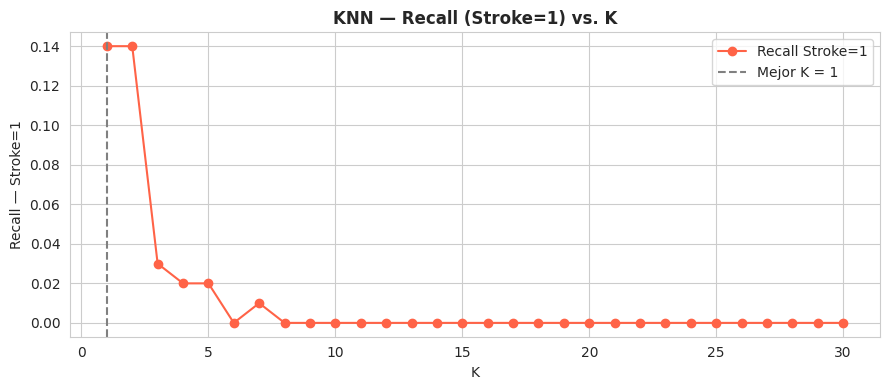

In [18]:

# ---
# Busqueda del mejor K buscando Recall de Stroke=1
# Con class_weight="balanced" para compensar el desbalance 95:1
k_range = range(1, 31)
recall_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, weights="distance",
                               metric="minkowski")
    knn.fit(X_train_scaled, y_train)
    y_pred_k = knn.predict(X_test_scaled)
    recall_scores.append(recall_score(y_test, y_pred_k))

best_k = recall_scores.index(max(recall_scores)) + 1
print(f"Mejor K (por Recall Stroke=1): {best_k}  "
      f"(recall: {max(recall_scores):.4f})")


plt.figure(figsize=(9, 4))
plt.plot(k_range, recall_scores, marker="o", color="tomato", label="Recall Stroke=1")
plt.axvline(best_k, linestyle="--", color="gray", label=f"Mejor K = {best_k}")
plt.title("KNN — Recall (Stroke=1) vs. K", fontweight="bold")
plt.xlabel("K"); plt.ylabel("Recall — Stroke=1")
plt.legend(); plt.tight_layout(); plt.show()


In [23]:
# ---
# Entrenar con el mejor K + umbral ajustado
knn_best = KNeighborsClassifier(n_neighbors=best_k, weights="distance", metric="minkowski")
knn_best.fit(X_train_scaled, y_train)
y_proba = knn_best.predict_proba(X_test_scaled)[:, 1]

# Bajar el umbral de decisión de 0.5 a 0.3 para capturar más Stroke=1
THRESHOLD = 0.3
y_pred = (y_proba >= THRESHOLD).astype(int)

print("\n=============================")
print(f"KNN (umbral={THRESHOLD})")
print("=============================")
print(classification_report(y_test, y_pred, target_names=["No Stroke", "Stroke"]))



KNN (umbral=0.3)
              precision    recall  f1-score   support

   No Stroke       0.96      0.96      0.96      1944
      Stroke       0.14      0.14      0.14       100

    accuracy                           0.92      2044
   macro avg       0.55      0.55      0.55      2044
weighted avg       0.92      0.92      0.92      2044



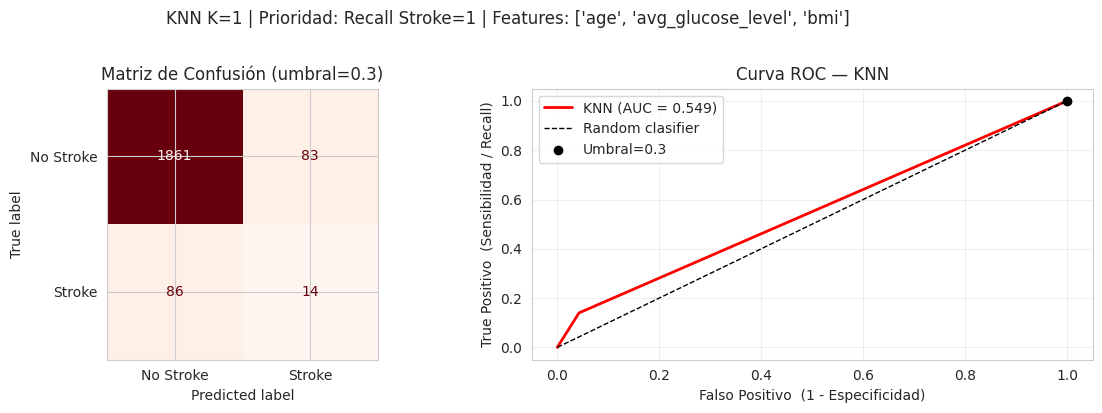

In [28]:
# Matriz de confusion - Curva ROC
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Stroke", "Stroke"])
disp.plot(ax=axes[0], colorbar=False, cmap="Reds")
axes[0].set_title(f"Matriz de Confusión (umbral={THRESHOLD})")

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

axes[1].plot(fpr, tpr, color="red", lw=2, label=f"KNN (AUC = {auc_score:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Random clasifier")

# umbral
idx = np.argmin(np.abs(thresholds - THRESHOLD))
axes[1].scatter(fpr[idx], tpr[idx], color="black", zorder=5,label=f"Umbral={THRESHOLD}")
axes[1].set_xlabel("Falso Positivo  (1 - Especificidad)")
axes[1].set_ylabel("True Positivo  (Sensibilidad / Recall)")
axes[1].set_title("Curva ROC — KNN")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle(f"KNN K={best_k} | Prioridad: Recall Stroke=1 | Features: {num_cols}", y=1.02)
plt.tight_layout(); plt.show()


In [ ]:
# Resumen 
tn, fp, fn, tp = cm.ravel()

print("RESUMEN KNN — PRIORIDAD DETECCIÓN STROKE=1")

print(f"Features usadas   : {num_cols}")
print(f"Mejor K           : {best_k}")
print(f"Umbral de decisión: {THRESHOLD}  (default=0.5)")
print(f"ROC-AUC           : {auc_score:.4f}")
print(f"Recall  Stroke=1  : {tp/(tp+fn):.4f}  ← metrica principal")
print(f"Precision Stroke=1: {tp/(tp+fp):.4f}")
print(f"Falsos negativos  : {fn}  (ACV no detectados )")
print(f"Falsos positivos  : {fp}  (alarmas innecesarias)")

RESUMEN KNN — PRIORIDAD DETECCIÓN STROKE=1
Features usadas   : ['age', 'avg_glucose_level', 'bmi']
Mejor K           : 1
Umbral de decisión: 0.3  (default=0.5)
ROC-AUC           : 0.5487
Recall  Stroke=1  : 0.1400  ← métrica principal
Precision Stroke=1: 0.1443
Falsos negativos  : 86  (ACV no detectados )
Falsos positivos  : 83  (alarmas innecesarias)
